In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')

ROOT_PROJECT = Path.cwd().parent
SRC = ROOT_PROJECT / 'src'
CHECKPOINT = ROOT_PROJECT / 'Data' / 'checkpoints'

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from utils.analyze import (
    get_sizes_groups,
    describe_clusters,
    describe_clusters_median
)

KMeansDrainLogs = CHECKPOINT / f'drain_logs-2026-07-27' / 'Kmeans_ver2'
print(f'Ruta para inicializar el proyecto: {KMeansDrainLogs}')

def detect_friendly_bot(user_agent, bot_patterns):
    ua = str(user_agent).lower()
    for bot_name, patterns in bot_patterns.items():
        for pattern in patterns:
            if pattern.lower() in ua:
                return bot_name
    return None

Ruta para inicializar el proyecto: /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/EntregableTec/Data/checkpoints/drain_logs-2026-07-27/Kmeans_ver2


## Analizis de KMeans n

In [2]:
X_drains = pd.read_parquet(str(KMeansDrainLogs))

In [3]:
X_drains['kmeans_labels'].unique()

array([3, 1, 5, 0, 4, 2], dtype=int32)

In [4]:
sizes_drains = get_sizes_groups(X_drains, kind = 'kmeans_labels')
sizes_drains

,kmeans_labels,tamano,porcentajes
0,0,374,0.0748
1,1,3379,0.6758
2,2,58,0.0116
3,3,390,0.0780
4,4,106,0.0212
5,5,693,0.1386


In [5]:
X_groups = get_sizes_groups(X_drains, kind = 'kmeans_labels')
X_groups

,kmeans_labels,tamano,porcentajes
0,0,374,0.0748
1,1,3379,0.6758
2,2,58,0.0116
3,3,390,0.0780
4,4,106,0.0212
5,5,693,0.1386


In [6]:
X_describe_clusters_drains = describe_clusters(X_drains, kind = 'kmeans_labels')
X_describe_clusters_drains

kmeans_labels,0,1,2,3,4,5
routes_visited,2.12,1.00,53.45,5.47,13.92,2.33
unique_routes,2.07,1.00,53.36,5.35,13.70,2.26
activity_window_ms,1720.61,0.01,476358.84,296415.15,340490.11,202128.85
mean_time_between_requests_ms,1519.37,0.01,10514.59,72157.44,29127.73,163965.47
median_time_between_requests_ms,1503.07,0.01,6031.16,55431.70,15336.42,163736.01
is_one_shot,0.00,1.00,0.00,0.00,0.00,0.00
dbscan_labels,5.41,0.99,2.38,3.67,-0.15,2.35
agglomerative_labels,3.63,3.00,2.00,0.00,0.83,1.00


In [7]:
view_drains = X_drains[X_drains['kmeans_labels'] == 2]

view_drains = view_drains.sort_values(by = 'routes_visited', ascending=True)
view_drains.head(20)

,time_window,routes_visited,unique_routes,activity_window_ms,mean_time_between_requests_ms,median_time_between_requests_ms,is_one_shot,ja4Digest,proxy.userAgent,proxy.clientIp,kmeans_labels,dbscan_labels,agglomerative_labels
2724,2026-06-10 07:20:00+00:00,27,27,554903,21342.423077,15266.0,False,t13d1011h2_61a7ad8aa9b6_3fcd1a44f3e3,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",216.73.217.172,2,-1,2
73504,2026-06-10 14:50:00+00:00,27,26,383896,14765.230769,1980.5,False,t13d2212h2_231e334592e8_36bf25f296df,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",40.77.167.75,2,-1,2
64238,2026-06-09 23:00:00+00:00,28,28,509885,18884.629630,8564.0,False,t13d181300_e8a523a41297_43ade6aba3df,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,66.249.79.228,2,-1,2
65194,2026-06-10 11:30:00+00:00,28,28,192902,7144.518519,6531.0,False,t13d181300_e8a523a41297_43ade6aba3df,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,66.249.79.237,2,-1,2
3377,2026-06-11 04:40:00+00:00,28,28,281567,10428.407407,10392.0,False,t13d1011h2_61a7ad8aa9b6_3fcd1a44f3e3,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",74.7.242.17,2,-1,2
62545,2026-06-09 07:00:00+00:00,28,28,591552,21909.333333,4430.0,False,t13d181300_e8a523a41297_43ade6aba3df,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,66.249.79.230,2,-1,2
32999,2026-06-09 23:30:00+00:00,29,26,513502,18339.357143,2124.0,False,t13d1516h2_8daaf6152771_d8a2da3f94cd,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,187.250.66.132,2,-1,2
65253,2026-06-10 12:20:00+00:00,29,29,303368,10834.571429,8916.0,False,t13d181300_e8a523a41297_43ade6aba3df,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,66.249.79.237,2,-1,2
72744,2026-06-10 02:20:00+00:00,30,30,495761,17095.206897,3017.0,False,t13d2212h2_231e334592e8_36bf25f296df,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",40.77.167.74,2,-1,2
72236,2026-06-09 11:50:00+00:00,30,30,483620,16676.551724,1686.0,False,t13d2212h2_231e334592e8_36bf25f296df,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",52.167.144.172,2,-1,2


## Demostración del modelo

El principal grupo de interés sera el grupo 2, el cuál tiende a tener un alto consumo de recursos dentro de la plataforma del negocio.

Como podrémos observar se compone principalmente de agentes crawlers de motores de busqueda, lo cual es comportamiento esperado, sin embargo, el grupo no conocido con userAgent 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36' es un buen candidato para ser inspeccionado.

                                     proxy.userAgent  visitas
0  Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...       16
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...        1
2  Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...       12
3  Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...       19
4  Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...       10


<Axes: >

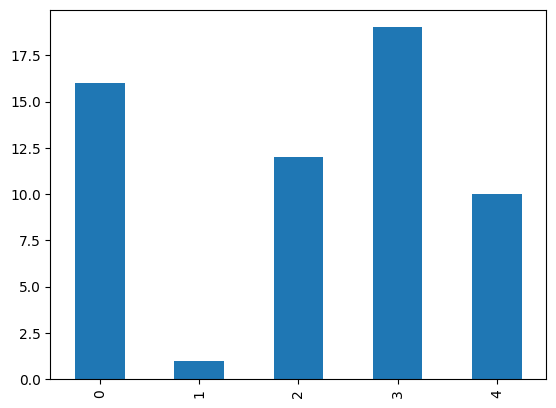

In [8]:
grupos_agents_by_name = view_drains.groupby('proxy.userAgent').size().reset_index().rename(columns={0:'visitas'})
print(grupos_agents_by_name)
grupos_agents_by_name['visitas'].plot(kind = 'bar')

In [9]:
sospechoso = grupos_agents_by_name['proxy.userAgent'][1]
view_drains[view_drains['proxy.userAgent'] == sospechoso]

,time_window,routes_visited,unique_routes,activity_window_ms,mean_time_between_requests_ms,median_time_between_requests_ms,is_one_shot,ja4Digest,proxy.userAgent,proxy.clientIp,kmeans_labels,dbscan_labels,agglomerative_labels
32999,2026-06-09 23:30:00+00:00,29,26,513502,18339.357143,2124.0,False,t13d1516h2_8daaf6152771_d8a2da3f94cd,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,187.250.66.132,2,-1,2


## Analisis de pipeline de DBSCAN

In [10]:
dbscan_analyze = get_sizes_groups(X_drains, kind = 'dbscan_labels')
X_describe_clusters_drains_dbscan = describe_clusters(X_drains, kind = 'dbscan_labels')

In [11]:
dbscan_analyze

,dbscan_labels,tamano,porcentajes
0,-1,421,0.0842
1,0,42,0.0084
2,1,3368,0.6736
3,2,453,0.0906
4,3,157,0.0314
5,4,31,0.0062
6,5,6,0.0012
7,6,293,0.0586
8,7,30,0.0060
9,8,44,0.0088


In [12]:
X_describe_clusters_drains_dbscan

dbscan_labels,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
routes_visited,12.44,5.00,1.0,2.00,3.00,3.00,3.00,2.00,7.00,6.00,...,8.00,2.0,2.00,10.00,5.00,4.00,4.00,56.43,2.0,53.33
unique_routes,12.12,5.00,1.0,2.00,3.00,3.00,3.00,2.00,7.00,6.00,...,8.00,2.0,2.00,10.00,5.00,4.00,4.00,56.43,1.0,53.33
activity_window_ms,210006.81,427392.74,0.0,191217.06,291602.90,65093.16,958.67,1244.19,457572.30,427934.68,...,489165.40,35.0,142.38,509024.50,253383.00,167756.00,279388.00,588983.29,70034.0,590423.33
mean_time_between_requests_ms,29399.52,106848.18,0.0,191217.06,145801.45,32546.58,479.33,1244.19,76262.05,85586.94,...,69880.77,35.0,142.38,56558.28,63345.75,55918.67,93129.33,10628.56,70034.0,11281.92
median_time_between_requests_ms,15884.68,91644.95,0.0,191217.06,145801.45,32546.58,479.33,1244.19,62505.88,63115.02,...,60232.00,35.0,142.38,50980.67,43949.80,56084.20,34962.60,10519.14,70034.0,10493.33
is_one_shot,0.00,0.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
kmeans_labels,2.90,3.00,1.0,5.00,5.00,5.00,0.00,0.00,3.00,3.00,...,3.00,0.0,0.00,4.00,3.00,3.00,3.00,2.00,5.0,2.00
agglomerative_labels,0.91,0.00,3.0,1.00,1.00,1.00,4.00,3.89,0.00,0.00,...,0.00,4.0,4.00,0.00,0.00,0.00,0.00,2.00,1.0,2.00


## Agglomerative CLuster Labels

In [13]:
agglomerative_analyze = get_sizes_groups(X_drains, kind = 'agglomerative_labels')
X_describe_clusters_drains_agglo = describe_clusters(X_drains, kind = 'agglomerative_labels')

In [14]:
agglomerative_analyze

,agglomerative_labels,tamano,porcentajes
0,0,456,0.0912
1,1,734,0.1468
2,2,102,0.0204
3,3,3379,0.6758
4,4,329,0.0658


In [15]:
X_describe_clusters_drains_agglo

agglomerative_labels,0,1,2,3,4
routes_visited,6.16,2.33,38.37,1.00,2.07
unique_routes,6.02,2.25,38.27,1.00,2.05
activity_window_ms,297266.79,191231.53,429398.55,0.01,988.52
mean_time_between_requests_ms,66363.66,155139.00,15557.24,0.01,955.66
median_time_between_requests_ms,50033.48,154922.35,7676.68,0.01,953.61
is_one_shot,0.00,0.00,0.00,1.00,0.00
kmeans_labels,3.11,4.72,2.86,1.00,0.00
dbscan_labels,3.20,2.43,0.92,0.99,5.69


## Elección del Modelo

K-Means fue seleccionado como modelo principal porque produjo seis grupos diferenciados, interpretables y manejables para revisión humana. Los grupos distinguen sesiones de una sola solicitud, actividad mínima rápida, actividad reducida pero espaciada, navegación moderada, navegación alta y navegación intensiva. Agglomerative Clustering encontró una estructura general muy semejante, confirmando la existencia de estos perfiles, aunque condensó algunos niveles de actividad. DBSCAN identificó patrones locales más específicos, pero generó una cantidad elevada de microclusters y observaciones consideradas ruido, lo que reduce su utilidad para un proceso de revisión humana.

## Análisis de separación de variables entre clusters

KMeans no proporciona coeficientes de importancia de variables de manera nativa. Por ello he realizado un análisis de los centroides para determinar qué caracteristicas presentan mayor diferenciación entre los grupos obtenidos.

Los resultados muestran que  `is_one_shot` presenta la mayor separación entre clusters (0.990), seguida de `routes_visited` (0.784) y `activity_window_ms` (0.686). Las variables relacionadas con el tiempo entre solicitudes también constribuyen a diferenciar los patrones de navegación aunque en menor medida.

Este análisis de centroides permite observar distintos perfiles de comportamiento. El cluster 2 presenta una intensidad de navegación considerablemente superior al resto, mientras que el Cluster 5 se caracteriza principalmente por mayores intervalos entre solicitudes. Por su parte el cluster 1 concentra el comportamiento en 1 sola interacción.

Estos resultados indican que las agrupaciones no dependen únicamente del volumen de navegación, sino de combinación de intensidad, duración y cadencia de actividad. Los valores deben interpretarse como capacidad descriptiva para diferenciar los clusters y no compo importancia causal de las variables.

CENTROIDES ESTANDARIZADOS


,routes_visited,unique_routes,activity_window_ms,mean_time_between_requests_ms,median_time_between_requests_ms,is_one_shot
kmeans_labels,,,,,,
0,-0.06,-0.06,-0.44,-0.37,-0.35,-1.44
1,-0.22,-0.22,-0.46,-0.39,-0.37,0.69
2,7.63,7.63,2.94,-0.25,-0.29,-1.44
3,0.44,0.43,1.66,0.57,0.37,-1.44
4,1.71,1.68,1.97,-0.00,-0.16,-1.44
5,-0.03,-0.03,0.98,1.78,1.81,-1.44


SEPARACIÓN DE VARIABLES ENTRE CLUSTERS


,feature,separation_score
0,is_one_shot,0.990
1,routes_visited,0.786
2,unique_routes,0.784
3,activity_window_ms,0.686
4,mean_time_between_requests_ms,0.577
5,median_time_between_requests_ms,0.568


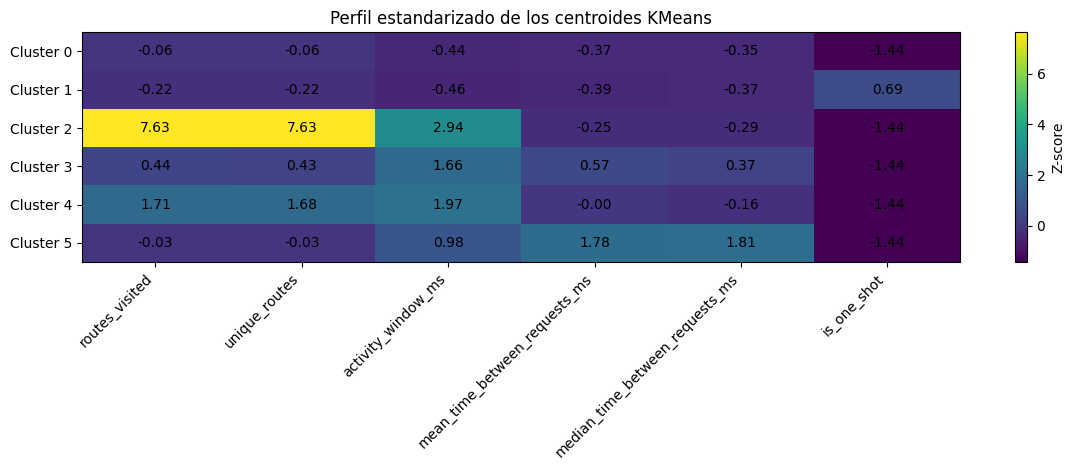

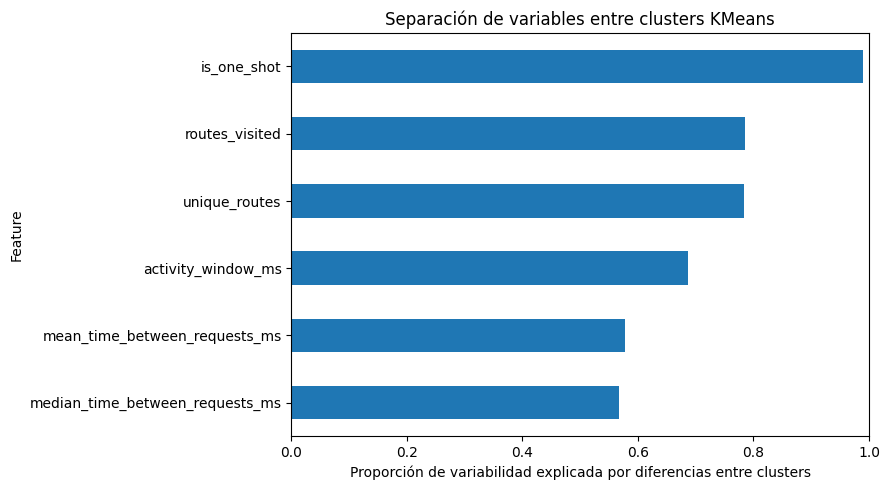

In [ ]:
from sklearn.preprocessing import StandardScaler

LABEL = "kmeans_labels"

candidate_features = [
    "routes_visited",
    "unique_routes",
    "activity_window_ms",
    "mean_time_between_requests_ms",
    "median_time_between_requests_ms",
    "is_one_shot",
]

FEATURES = [col for col in candidate_features if col in X_drains.columns]

work = X_drains[[LABEL] + FEATURES].dropna().copy()

if "is_one_shot" in work.columns:
    work["is_one_shot"] = work["is_one_shot"].astype(int)


scaler = StandardScaler()

Z = pd.DataFrame(
    scaler.fit_transform(work[FEATURES]),
    columns=FEATURES,
    index=work.index
)

Z[LABEL] = work[LABEL].values

centroids_z = (
    Z.groupby(LABEL)[FEATURES]
    .mean()
)

print("CENTROIDES ESTANDARIZADOS")
display(centroids_z.round(2))

Z_features = Z[FEATURES]

overall_mean = Z_features.mean()

cluster_sizes = (
    Z.groupby(LABEL)
    .size()
)

between_ss = pd.Series(0.0, index=FEATURES)

for cluster_id, n in cluster_sizes.items():
    difference = centroids_z.loc[cluster_id] - overall_mean
    between_ss += n * (difference ** 2)

total_ss = ((Z_features - overall_mean) ** 2).sum()

separation_score = (
    between_ss / total_ss
).sort_values(ascending=False)

separation_df = pd.DataFrame({
    "feature": separation_score.index,
    "separation_score": separation_score.values
})

print("SEPARACIÓN DE VARIABLES ENTRE CLUSTERS")
display(separation_df.round(3))

fig, ax = plt.subplots(
    figsize=(12, max(4, len(centroids_z) * 0.8))
)

image = ax.imshow(
    centroids_z.values,
    aspect="auto"
)

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right")

ax.set_yticks(range(len(centroids_z.index)))
ax.set_yticklabels(
    [f"Cluster {x}" for x in centroids_z.index]
)

for i in range(centroids_z.shape[0]):
    for j in range(centroids_z.shape[1]):
        ax.text(
            j,
            i,
            f"{centroids_z.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Perfil estandarizado de los centroides KMeans")
fig.colorbar(image, ax=ax, label="Z-score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))

separation_score.sort_values().plot(
    kind="barh"
)

plt.xlabel("Proporción de variabilidad explicada por diferencias entre clusters")
plt.ylabel("Feature")
plt.title("Separación de variables entre clusters KMeans")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()